<a href="https://colab.research.google.com/github/Angana20/Maincrafts-Technology/blob/main/Task2_Titanic_Survival_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK-2 Titanic Dataset**

This dataset contains passenger details (age, class, gender, etc.) and whether they survived.
My task is to analyze survival patterns and visualize them.

1. Load Titanic dataset from Kaggle

In [ ]:
import pandas as pd
df =pd.read_csv('train.csv')
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



# 2. Clean data (handle missing values like Age)

In [ ]:
print("Missing values per column:\n", df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())


df.dropna(subset=['Embarked'], inplace=True)

print("\nData cleaned. Missing ages filled.")

Missing values per column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data cleaned. Missing ages filled.


# **3.Answer questions such as:**

**Who survived more: males or females?**


In [ ]:
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print(f"Survival Rate:\n{gender_survival}")


Survival Rate:
Sex
female    74.038462
male      18.890815
Name: Survived, dtype: float64



**Did passenger class affect survival chances?**


In [ ]:
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print(f"Survival Rate by Class:\n{class_survival}")

Survival Rate by Class:
Pclass
1    62.616822
2    47.282609
3    24.236253
Name: Survived, dtype: float64



**What was the survival rate by age group?**

In [ ]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)


age_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
print(f"Survival Rate by Age Group:\n{age_survival}")


Survival Rate by Age Group:
AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          39.690722
Senior         19.047619
Name: Survived, dtype: float64


# **4.Visualize using Seaborn / Matplotlib:**

 **Bar chart of survival by gender.**

/tmp/ipykernel_9229/2865394493.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, palette="viridis")


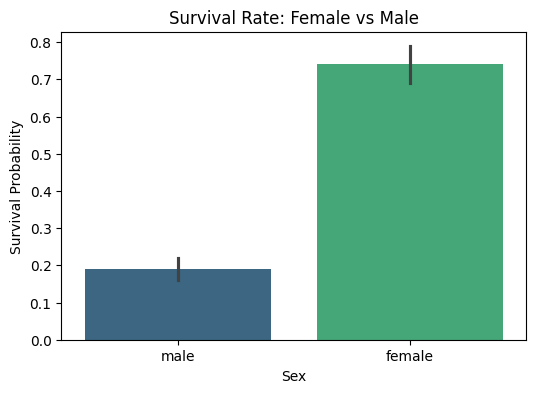

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x="Sex", y="Survived", data=df, palette="viridis")
plt.title("Survival Rate: Female vs Male")
plt.ylabel("Survival Probability")
plt.show()

# **Bar chart of survival by class.**

/tmp/ipykernel_9229/2989063378.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, palette="magma")


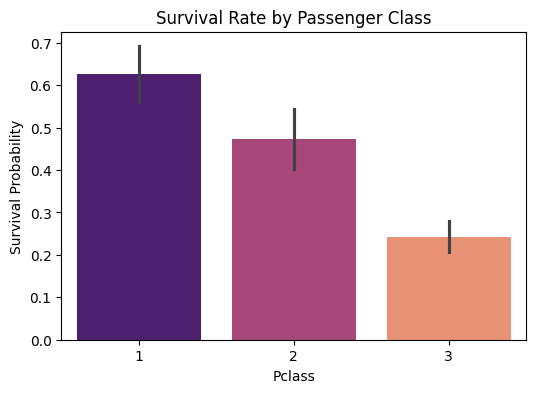

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x="Pclass", y="Survived", data=df, palette="magma")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Probability")
plt.show()

# **Histogram of passenger ages.**

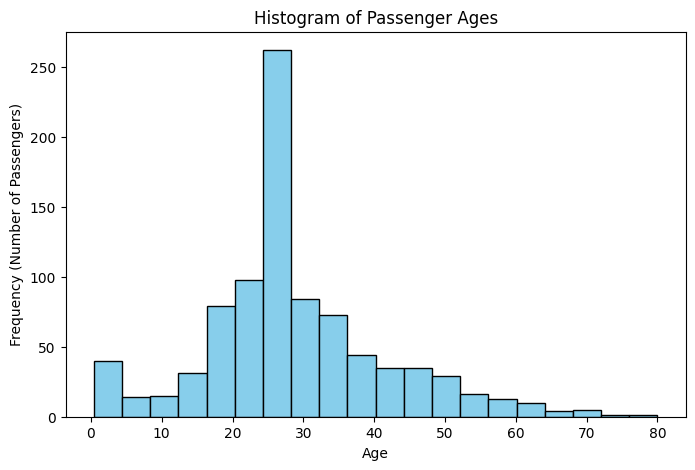

In [ ]:
plt.figure(figsize=(8, 5))
df['Age'].plot(kind='hist', bins=20, color='skyblue', edgecolor='black')

plt.title("Histogram of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency (Number of Passengers)")

plt.show()

**Conclusion**
The analysis of the Titanic dataset reveals that survival was not random; instead, it was strongly influenced by gender and social standing, with females and first-class passengers having significantly higher survival rates. By cleaning messy data and visualizing age distributions, this task demonstrates how data science techniques can uncover critical patterns and answer essential business questions.